# Смена директории


In [1]:
%cd ..

/Users/uzumnasiya/HSE/Year_Project


# Импорт библиотек


In [2]:
import logging
import warnings
import time


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yaml
import joblib
import shap
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CatBoostEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from utils.dev_utils import get_pool
from utils.pipeline_utils import CustomPreprocessor
from utils.metrics import MetricCalculator, metric_funcs
from utils.style.styler import style_metrics
from utils.style.html_output import print_multiple_html
from utils.plot_utils import plot_gini_by_period_styled, plot_roc_by_masks
from utils.config_utils import get_confg

In [3]:
logging.getLogger().setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_palette('bright')


pd.options.display.float_format = "{:.2f}".format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

In [4]:
%load_ext autoreload
%autoreload 2
%aimport utils.plot_utils
%aimport utils.eda_utils
%aimport utils.style_utils
%aimport utils.psi
%aimport utils.style.styler

In [5]:
metr_funcs = {
    'roc_auc': metric_funcs.roc_auc_score_nan,
    'gini': metric_funcs.gini_score_nan,
    'precision': metric_funcs.precision,
    'recall': metric_funcs.recall
}

stats_funcs = {
    'obs_cnt': lambda y_true, data: len(y_true),
    'target_cnt': lambda y_true, data: sum(y_true),
    'DR': lambda y_true, data: sum(y_true) / len(y_true)
}

# Класс для расчета метрик
metr_calc = MetricCalculator(metr_funcs=metr_funcs, stats_funcs=stats_funcs)


STYLE_CONFIG = {
    'percent_cols': ['gini', 'roc_auc', 'DR', 'precision', 'recall'],
    'int_cols': ['obs_cnt', 'target_cnt'],
    'gradient_cols': ['gini', 'roc_auc', 'precision', 'recall'],
    'gradient_cmap': 'RdYlGn',
}

In [6]:
def metrics_split(data, group_cols, metr_calc, pred_cols=['lg_model_preds'], target='target', asc=True):
    """Упрощенный интерфес для расчета метрик"""

    metr_split = metr_calc.calculate(
        data, true_col=target, pred_cols=pred_cols, group_cols=group_cols)
    metr_split = (
        metr_split
        .sort_values(by=group_cols, ascending=asc)
        .set_index(group_cols)
    )

    return metr_split

# Входные данные


## Загрузка данных


In [7]:
data = pd.read_parquet('./data/processed/data.pqt')

data.shape

(1097231, 633)

## Загрузка предсказаний DL

In [8]:
gru_preds = pd.read_parquet(r'./data/model_preds/gru_preds.pqt')
mlp_preds = pd.read_parquet(r'./data/model_preds/mlp_preds.pqt')
rnn_preds = pd.read_parquet(r'./data/model_preds/rnn_preds.pqt')

In [9]:
display(rnn_preds.head(4))
rnn_preds.shape

,TransactionID,target,prediction,sample_type
0,3230924,0.00,0.57,TRAIN
1,3023634,0.00,0.03,TRAIN
2,3210739,0.00,0.01,TRAIN
3,3020767,0.00,0.39,TRAIN


(590540, 4)

In [10]:
display(mlp_preds.head(4))
mlp_preds.shape

,TransactionID,target,sample_type,mlp_preds
243924,3230924,0.00,TRAIN,0.00
36634,3023634,0.00,TRAIN,0.00
164336,3151336,0.00,TEST,0.00
223739,3210739,0.00,TRAIN,0.00


(590540, 4)

In [11]:
display(gru_preds.head(4))
gru_preds.shape

,TransactionID,pred_prob,target,train_test_oot
0,3039554,0.03,0.00,train
1,3055472,0.01,0.00,train
2,3065777,0.02,0.00,train
3,3138252,0.01,0.00,train


(590540, 4)

In [12]:
sample = rnn_preds.merge(mlp_preds[['TransactionID', 'mlp_preds']], on='TransactionID', how='outer').rename(columns={'prediction': 'rnn_preds'})
sample = sample.merge(gru_preds[['TransactionID', 'pred_prob']], on='TransactionID', how='outer').rename(columns={'pred_prob': 'gru_preds'})

In [13]:
sample.head()

,TransactionID,target,rnn_preds,sample_type,mlp_preds,gru_preds
0,2987000,0.00,0.08,TRAIN,0.01,0.04
1,2987001,0.00,0.39,TRAIN,0.00,0.07
2,2987002,0.00,0.08,TEST,0.01,0.03
3,2987003,0.00,0.35,TEST,0.00,0.89
4,2987004,0.00,0.08,TEST,0.00,0.36


In [14]:
data = data.merge(sample[['TransactionID', 'rnn_preds', 'mlp_preds', 'gru_preds']], on='TransactionID', how='outer')

## Валидные переменные


In [15]:
path = r'./docs/valid_features.xlsx'
valid_features_data = pd.read_excel(path, index_col=False)

# Конфиги/константы

In [16]:
TARGET = 'target'
DATE_MONTH = 'date_month'
DATE_QUARTAL = 'date_quartal'

FEATURES = get_confg(r'./models/params/features.yaml', 'FINAL_FEATURES') + ['rnn_preds', 'mlp_preds', 'gru_preds']

# FEATURES = valid_features_data.loc[(
#     valid_features_data['valid_flag'] == 1)]['attribute'].values
CAT_FEATURES = sorted(set(FEATURES) & set(
    data.select_dtypes(include=["object", "category"]).columns))
NUM_FEATURES = sorted(set(FEATURES) & set(
    data.select_dtypes(include=["number"]).columns))

TRAIN_MASK = (data['sample_type'] == 'TRAIN')
TEST_MASK = (data['sample_type'] == 'TEST')
OOT_MASK = (data['sample_type'] == 'OOT')

DEV_MASK = (data['competition_sample_type'] == 'TRAIN')

# Метрики DL моделей

In [17]:
metr_funcs = {
    'gini': metric_funcs.gini_score_nan,
}
gini_metr_calc = MetricCalculator(metr_funcs=metr_funcs)

In [18]:
metr_split = metrics_split(
    data=sample,
    target=TARGET,
    pred_cols=['rnn_preds', 'mlp_preds', 'gru_preds'],
    group_cols='sample_type',
    metr_calc=gini_metr_calc,
    asc=False
)

(metr_split
    .pivot_table(index='level_1', 
                 columns=metr_split.index, 
                 values='gini')[['TRAIN', 'TEST', 'OOT']]
    .style
    .format("{:.1%}")
    .background_gradient(cmap='RdYlGn', axis=None)
)

sample_type,TRAIN,TEST,OOT
level_1,,,
gru_preds,67.3%,63.9%,60.7%
mlp_preds,97.1%,86.9%,69.7%
rnn_preds,76.9%,73.2%,68.9%


# Обучение catboost с предсказаниями DL

In [19]:
# Берем только наблюдения с взаимной целевой и преобразуем кат. фичи
dev_sample = data.loc[DEV_MASK].copy()

# Трансформируем категориальные переменные
dev_sample = CustomPreprocessor(
    cat_features=CAT_FEATURES).transform(dev_sample)

In [20]:
train_pool = get_pool(dev_sample, TARGET, TRAIN_MASK, FEATURES, CAT_FEATURES)
test_pool = get_pool(dev_sample, TARGET, TEST_MASK, FEATURES, CAT_FEATURES)
oot_pool = get_pool(dev_sample, TARGET, OOT_MASK, FEATURES, CAT_FEATURES)

In [21]:
# Параметры модели
final_params = {'iterations': 250,
 'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'early_stopping_rounds': 20,
 'verbose': 0,
 'random_seed': 42,
 'depth': 7,
 'learning_rate': 0.1205712628744377,
 'colsample_bylevel': 0.0638792635777333}

In [22]:
# Обучение модели
model = CatBoostClassifier(**final_params, cat_features=CAT_FEATURES)
model.fit(train_pool, eval_set=test_pool, use_best_model=True, plot=False)

In [23]:
# Предсказания для всего набора
pipeline = Pipeline([
    ('preprocessor', CustomPreprocessor(cat_features=CAT_FEATURES)),
    ('model', model),
])

data['cb_model_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

## Метрики


In [24]:
# По сэмплам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='cb_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,cb_model_preds,98.5%,97.0%,95.5%,77.8%,350 849,12 276,3.5%
TEST,cb_model_preds,95.0%,90.0%,83.3%,64.4%,150 365,5 273,3.5%
OOT,cb_model_preds,90.6%,81.3%,67.2%,45.4%,89 326,3 114,3.5%


In [25]:
# По месяцам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='cb_model_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,cb_model_preds,96.5%,93.0%,90.1%,68.8%,134 339,3 401,2.5%
2020-02,cb_model_preds,97.7%,95.5%,92.5%,74.1%,86 467,3 469,4.0%
2020-03,cb_model_preds,97.8%,95.6%,93.6%,78.1%,95 121,3 832,4.0%
2020-04,cb_model_preds,97.3%,94.6%,91.7%,73.5%,98 615,3 898,4.0%
2020-05,cb_model_preds,97.9%,95.9%,91.7%,73.9%,86 672,2 949,3.4%
2020-06,cb_model_preds,90.6%,81.2%,67.1%,45.2%,86 572,2 995,3.5%
2020-07,cb_model_preds,92.1%,84.2%,69.9%,48.7%,2 754,119,4.3%


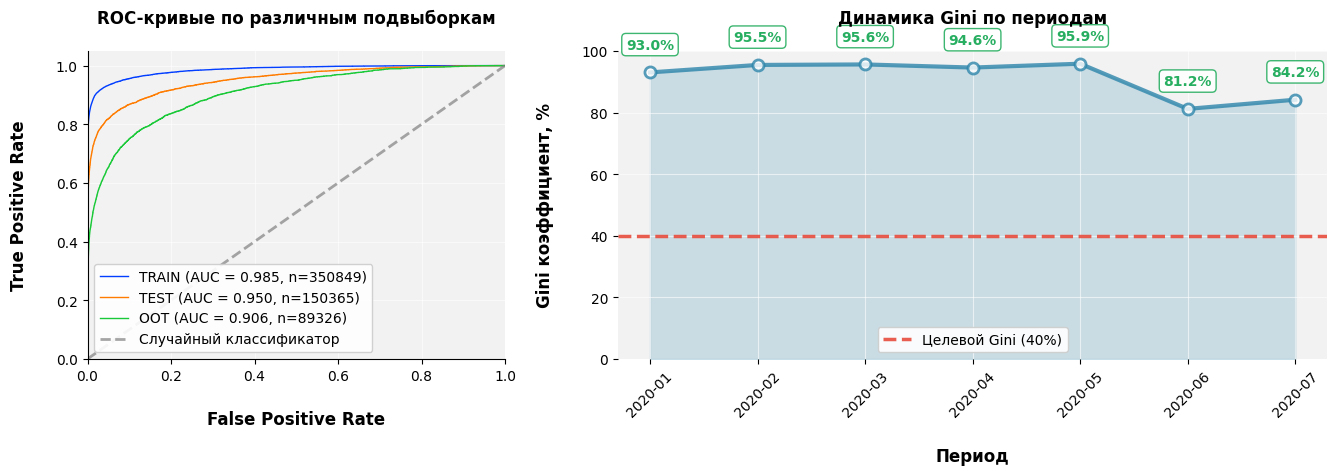

In [26]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={
                         'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'cb_model_preds', masks_dict,
                  figsize=(8, 4), palette='bright',
                  title='ROC-кривые по различным подвыборкам',
                  ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                           figsize=(8, 4),
                           target_gini=40,
                           title='Динамика Gini по периодам',
                           ax=ax)